In [343]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


df = pd.read_csv('../datasets/insurance - insurance.csv')


In [344]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
1260,32,female,20.520,0,no,northeast,4544.23480
761,23,male,35.200,1,no,southwest,2416.95500
1018,54,female,35.815,3,no,northwest,12495.29085
925,50,male,32.110,2,no,northeast,25333.33284
437,35,male,28.900,3,no,southwest,5926.84600
325,40,male,34.105,1,no,northeast,6600.20595
588,61,female,35.910,0,no,northeast,13635.63790
502,51,male,23.210,1,yes,southeast,22218.11490
889,57,male,33.630,1,no,northwest,11945.13270
628,58,male,38.000,0,no,southwest,11365.95200


In [345]:
df.drop(columns = 'region', inplace= True)


In [346]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [347]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [348]:
df.duplicated().sum()

np.int64(1)

In [349]:
df.drop_duplicates(inplace=True)


In [350]:
df.duplicated().sum()

np.int64(0)

In [351]:
df = df.dropna()

In [352]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 73.1 KB


In [353]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [354]:
# cat = ['sex', 'smoker']

# ohe = OneHotEncoder(sparse_output=False)

# encoded = ohe.fit_transform(df[cat])

# encoded


In [355]:
# encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cat))
# encoded_df

In [356]:
# df = pd.concat([df, encoded_df], axis=1)

In [357]:
# df.sample(5)

In [358]:
# df.drop(cat, axis=1, inplace= True)

In [359]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
new_sex = ohe.fit_transform(df[['sex']])
df['sex'] = new_sex

In [360]:
encoded_smoker = ohe.fit_transform(df[['smoker']])
df['smoker'] = encoded_smoker

In [361]:
df

,age,sex,bmi,children,smoker,charges
0,19,0.0,27.900,0,1.0,16884.92400
1,18,1.0,33.770,1,0.0,1725.55230
2,28,1.0,33.000,3,0.0,4449.46200
3,33,1.0,22.705,0,0.0,21984.47061
4,32,1.0,28.880,0,0.0,3866.85520
...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0.0,10600.54830
1334,18,0.0,31.920,0,0.0,2205.98080
1335,18,0.0,36.850,0,0.0,1629.83350
1336,21,0.0,25.800,0,0.0,2007.94500


In [362]:
df['charges'] = np.log1p(df['charges'])

<Axes: >

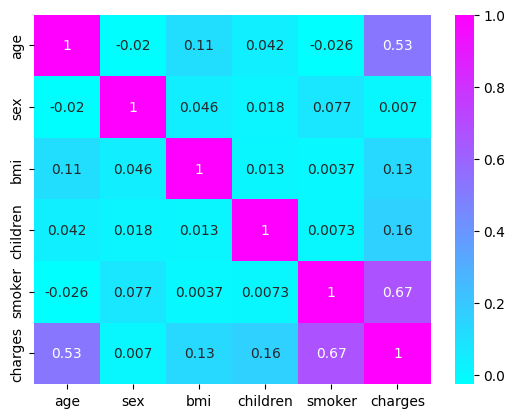

In [363]:
corr = df.corr()
sns.heatmap(corr,cmap='cool',annot=True)

## splitting dataset

In [364]:
df = df.dropna()

In [365]:
X = df.drop(columns = 'charges')
y = df['charges']

In [366]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

np.float64(-0.08955835073325419)

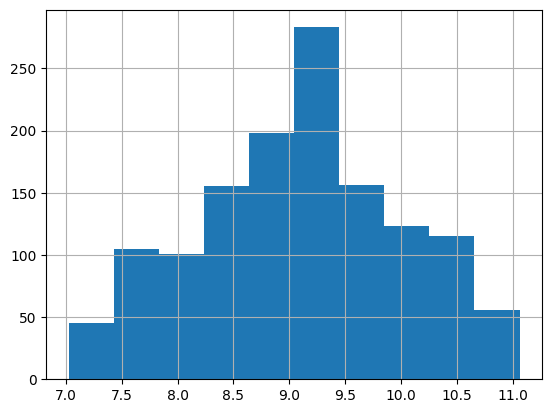

In [367]:
df['charges'].hist()
df['charges'].skew()

<Axes: >

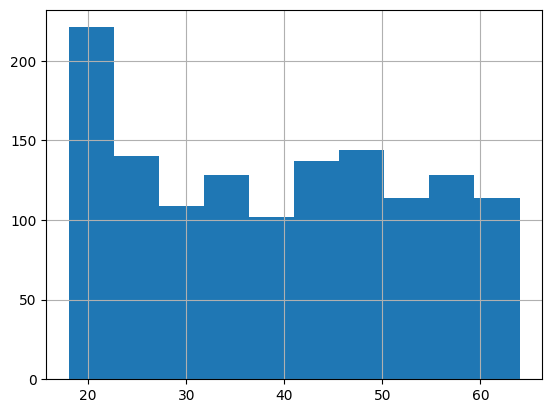

In [368]:
df['age'].hist()


<Axes: >

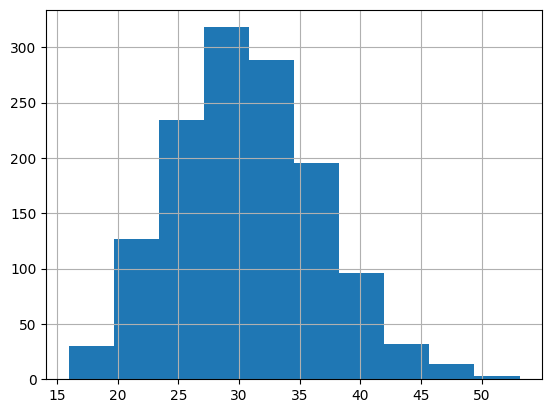

In [369]:
df['bmi'].hist()

In [370]:
# num_cols = ['age', 'bmi','children']

# scaler = StandardScaler()

# X.loc[:, num_cols] = scaler.fit_transform(X[num_cols])
# # X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

In [372]:
scale = StandardScaler()
X[['age','bmi','children']] = scale.fit_transform(X[['age','bmi','children']])

In [373]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [374]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [375]:
y_pred = lr.predict(X_test)

In [376]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test,y_pred)
accuracy

0.8212560706745113

## Regularization


## Ridge

In [377]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridgeRegressor = Ridge()

In [385]:
parameter = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridgeRegressor, param_grid=parameter,scoring='neg_mean_squared_error', cv=5)
ridgecv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

In [386]:
print(ridgecv.best_params_)
print(ridgecv.best_score_)

{'alpha': 1}
-0.2102184091372561


In [387]:
ridge_pred = ridgecv.predict(X_test)

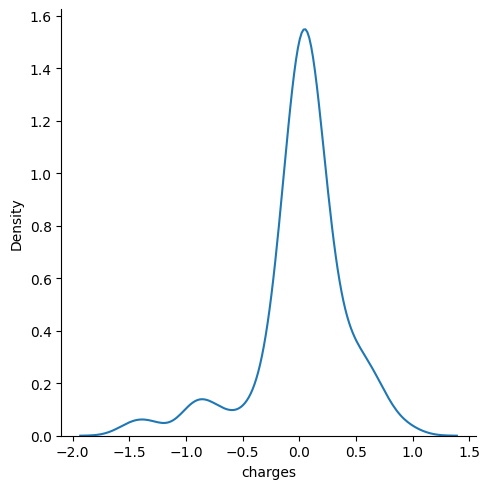

In [388]:
sns.displot(ridge_pred-y_test, kind = 'kde')

In [389]:
score = r2_score(ridge_pred,y_test)
score

0.7542043920234631

## Lasso

In [398]:
from sklearn.linear_model import Lasso, LassoCV
lasso = Lasso()

In [399]:
# parameter = {'alpha':[1,2,5,6,7,8,9,10,20,30,40,50,60,70,80,90],'max_iter': [100,200,300,500,1000,2000]}
# lassocv = GridSearchCV(lasso, param_grid=parameter,scoring='neg_mean_squared_error', cv=5)
lasso = LassoCV(cv=5,random_state=42)
lasso.fit(X_train,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [400]:
lasso_pred = lasso.predict(X_test)

In [401]:
score1 = r2_score(lasso_pred,y_test)
score1

0.7556013536735697